Max diff: 8.88e-16


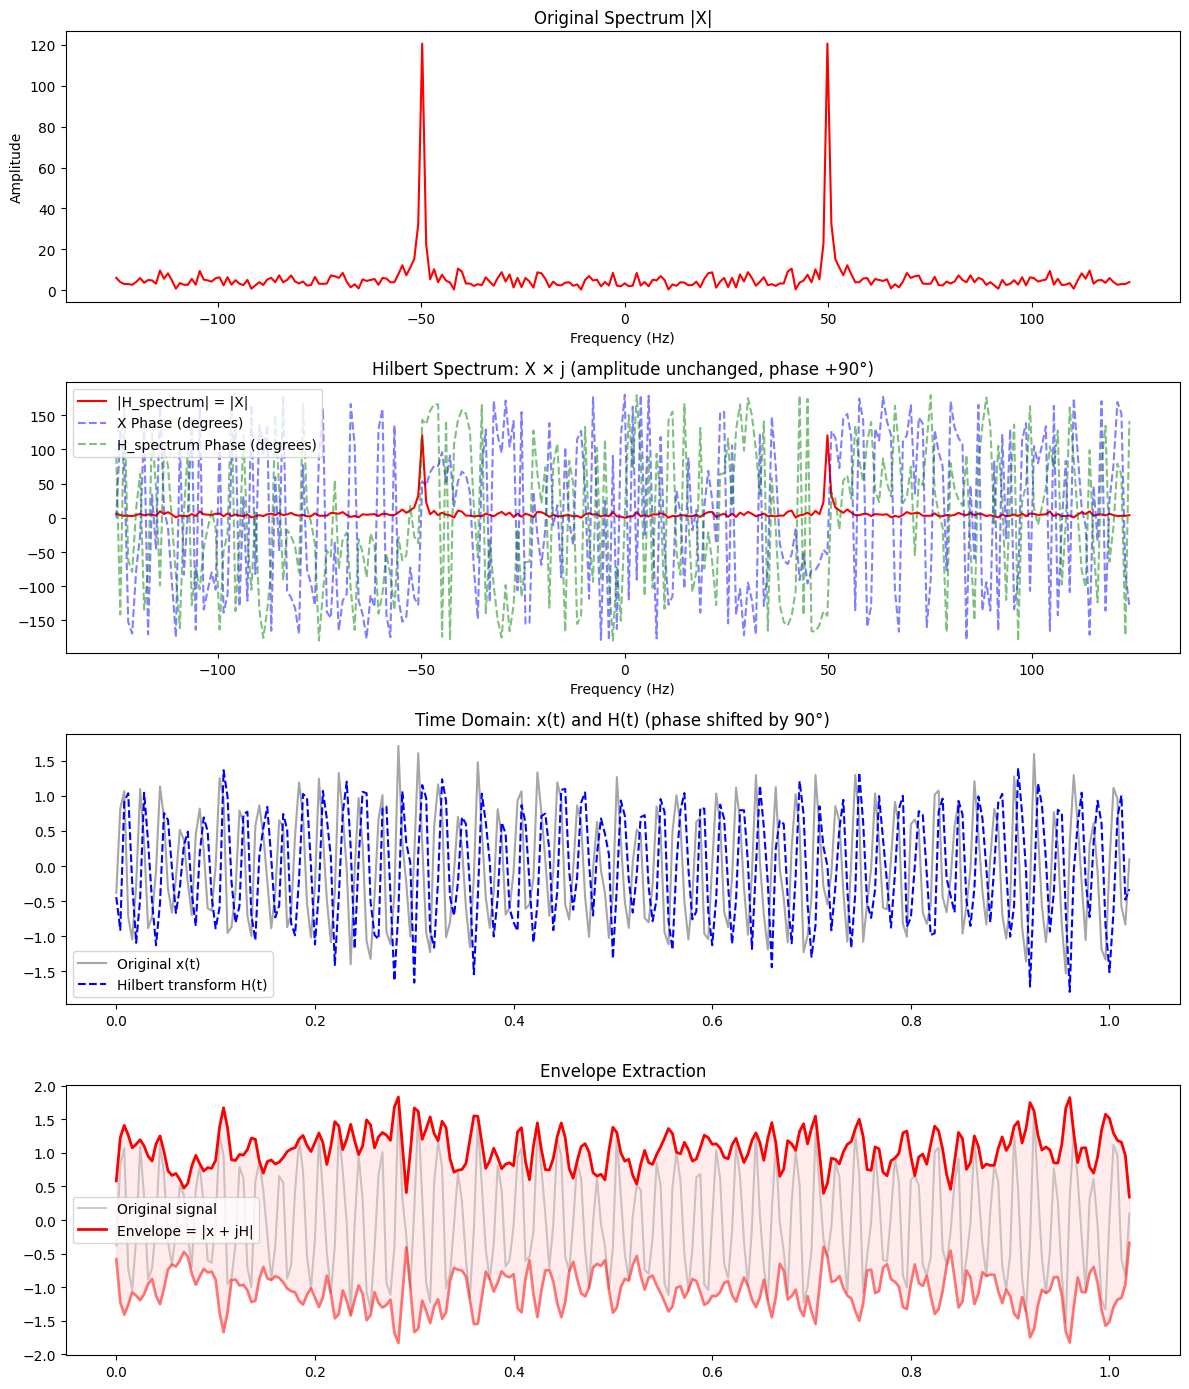

In [3]:
import numpy as np
from matplotlib import pyplot as plt

def sampling(t, N):
    return np.sin(2*np.pi*50*t) + 0.3*np.random.randn(N)

fs = 250
N = 256
t = np.arange(N) / fs
x = sampling(t, N)

# ===== 变换 =====
X = np.fft.fft(x)
f = np.fft.fftfreq(N, d=1/fs)

# ===== 频域实现希尔伯特变换 =====
# 正频率 × j（相位 +90°），DC 置零
H_spectrum = np.zeros_like(X)
H_spectrum = -1j * np.sign(f) * X # 根据频率符号，将正频率设为 -j，负频率设为 j
# 反变换得到希尔伯特变换结果
H = np.fft.ifft(H_spectrum, n=N).real # 取实部，得到希尔伯特变换结果
# 构造解析信号，提取包络
z = x + 1j * H
envelope = np.abs(z)

# ===== 验证：和 scipy 对比 =====
from scipy.signal import hilbert
envelope_scipy = np.abs(hilbert(x))
print(f"Max diff: {np.max(np.abs(envelope - envelope_scipy)):.2e}")

# ===== 绘图（显示时再 shift，让频率轴从负到正） =====
f_shifted = np.fft.fftshift(f)
X_shifted = np.fft.fftshift(X)
H_spectrum_shifted = np.fft.fftshift(H_spectrum)

# ===== 绘图 =====
fig, ax = plt.subplots(4, 1, figsize=(12, 14))

# 1. 原信号频谱
ax[0].plot(f_shifted, np.abs(X_shifted), color="r")
ax[0].set_title("Original Spectrum |X|")
ax[0].set_xlabel("Frequency (Hz)")
ax[0].set_ylabel("Amplitude")

# 2. 希尔伯特变换频谱（乘以 j 后，幅度不变，相位变了）
ax[1].plot(f_shifted, np.abs(H_spectrum_shifted), color="r", label="|H_spectrum| = |X|")
ax[1].plot(f_shifted, np.angle(X_shifted, deg=True), color="blue", alpha=0.5, label="X Phase (degrees)", linestyle="--")
ax[1].plot(f_shifted, np.angle(H_spectrum_shifted, deg=True), color="green", alpha=0.5, label="H_spectrum Phase (degrees)", linestyle="--")
ax[1].set_title("Hilbert Spectrum: X × j (amplitude unchanged, phase +90°)")
ax[1].set_xlabel("Frequency (Hz)")
ax[1].legend()

# 3. 时域：原信号 vs 希尔伯特变换
ax[2].plot(t, x, label="Original x(t)", color="gray", alpha=0.7)
ax[2].plot(t, H, label="Hilbert transform H(t)", color="blue", linestyle="--")
ax[2].set_title("Time Domain: x(t) and H(t) (phase shifted by 90°)")
ax[2].legend()

# 4. 包络
ax[3].plot(t, x, alpha=0.4, color="gray", label="Original signal")
ax[3].plot(t, envelope, color="r", linewidth=2, label="Envelope = |x + jH|")
ax[3].plot(t, -envelope, color="r", linewidth=2, alpha=0.5)
ax[3].fill_between(t, envelope, -envelope, alpha=0.08, color="r")
ax[3].set_title("Envelope Extraction")
ax[3].legend()

plt.tight_layout()
plt.show()


Q:为什么相位相差90度之后组装成z,然后再算np.abs(z)，就得到包络了?  
A:因为这一步本质上是在把**一个实信号补成“复平面里的旋转向量”**。
补出来之后，这个复向量的**模长**，刚好就是原信号瞬时振幅，也就是包络。

---

先说结论：

设原信号是单分量 AM 形式

$$
x(t)=A(t)\cos\phi(t)
$$

它的希尔伯特变换近似是

$$
\hat x(t)=A(t)\sin\phi(t)
$$

于是构造解析信号

$$
z(t)=x(t)+j\hat x(t)
$$

就得到

$$
z(t)=A(t)\cos\phi(t)+jA(t)\sin\phi(t)
= A(t)e^{j\phi(t)}
$$

所以它的模长就是

$$
|z(t)|=|A(t)e^{j\phi(t)}|=A(t)
$$

这就是包络。

---

## 直观理解

原来的实信号只有一条轴上的投影：

$$
x(t)=A(t)\cos\phi(t)
$$

你只能看到“横坐标”。

而希尔伯特变换给出的，是和它**正交的 90^\circ 分量**：

$$
\hat x(t)=A(t)\sin\phi(t)
$$

这相当于把“纵坐标”也补出来了。

于是复信号

$$
z(t)=x(t)+j\hat x(t)
$$

在复平面上就变成一个旋转向量：

* 实部：横坐标
* 虚部：纵坐标
* 向量长度：瞬时振幅
* 向量角度：瞬时相位

所以

$$
|z(t)|=\sqrt{x^2(t)+\hat x^2(t)}
$$

代入上面那对正交分量：

$$
|z(t)|=\sqrt{A^2(t)\cos^2\phi(t)+A^2(t)\sin^2\phi(t)}
$$

$$
= A(t)\sqrt{\cos^2\phi(t)+\sin^2\phi(t)}
= A(t)
$$

包络就出来了。

---

## 为什么“相差 90°”这么关键

因为只有相差 (90^\circ)，这两个分量才像直角坐标系里的两个正交轴：

$$
(\cos\phi,\ \sin\phi)
$$

这样平方和才能把相位项消掉，只剩振幅：

$$
\cos^2\phi+\sin^2\phi=1
$$

如果不是正交的，比如随便配一个别的相位差，模长里就会混进相位项，不能干净地得到包络。